# Pharmacy Access in Northern Vermont

Driving time analysis for pharmacies in **Caledonia**, **Orleans**, **Lamoille**, and **Washington** counties.

This notebook:
1. Loads **active** pharmacy rows from `pharmacies_active.json` (build with `00-pharmacies.ipynb`)
2. Clusters nearby pharmacies into centroids to reduce API calls
3. Downloads county boundaries from US Census TIGER/Line
4. Loads address sample points from CSV files
5. Computes driving time to the nearest pharmacy via the **Google Routes API**
6. Visualizes results as an interactive heat map
7. Reports descriptive statistics on pharmacy access

**Budget**: Google Routes API Compute Route Matrix Essentials — 10,000 free elements/month, then $5/1,000. Hard cap: **12,000 elements ($10 max spend)**.


In [1]:
import json
import math
import os
import time
from pathlib import Path

from dotenv import load_dotenv
load_dotenv(Path("../.env"))

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

ADDRESSES_DIR = DATA_DIR / "addresses"

TARGET_COUNTIES = {
    "Caledonia": "50005",
    "Orleans": "50019",
    "Lamoille": "50015",
    "Washington": "50023",
}
COUNTY_FIPS_TO_NAME = {v: k for k, v in TARGET_COUNTIES.items()}

GOOGLE_API_KEY = os.environ.get("GOOGLE_ROUTES_API_KEY", "")
ROUTE_MATRIX_URL = "https://routes.googleapis.com/distanceMatrix/v2:computeRouteMatrix"
ELEMENT_BUDGET = 12_000  # 10k free + $10 at $5/1000
CLUSTER_RADIUS_MILES = 1.5
TOP_K_CANDIDATES = 4

assert GOOGLE_API_KEY, (
    "Set GOOGLE_ROUTES_API_KEY in .env before running."
)
print(f"API key loaded: {GOOGLE_API_KEY[:8]}...")

API key loaded: AIzaSyAs...


## 1. Active pharmacies

Load `data/pharmacies_active.json`, produced by **`00-pharmacies.ipynb`** (Places search, closed-site filter).


In [2]:
PHARMACIES_ACTIVE = DATA_DIR / "pharmacies_active.json"
assert PHARMACIES_ACTIVE.exists(), (
    f"Missing {PHARMACIES_ACTIVE}. Run notebooks/00-pharmacies.ipynb first."
)

pharmacies = pd.read_json(PHARMACIES_ACTIVE, orient="records")
print(f"Loaded {len(pharmacies)} active pharmacies from {PHARMACIES_ACTIVE.name}")


Loaded 224 active pharmacies from pharmacies_active.json


## 2. Cluster Nearby Pharmacies

Pharmacies within 0.5 miles of each other are grouped into a single centroid. This reduces destination count for the Route Matrix API, saving budget without losing meaningful geographic resolution.

In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3959  # Earth radius in miles
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2
         + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2))
         * math.sin(dlon / 2) ** 2)
    return 2 * R * math.asin(math.sqrt(a))


def cluster_pharmacies(df: pd.DataFrame, radius_miles: float) -> pd.DataFrame:
    assigned = set()
    clusters = []
    for i in df.index:
        if i in assigned:
            continue
        members = [i]
        assigned.add(i)
        for j in df.index:
            if j in assigned:
                continue
            d = haversine_miles(df.loc[i, "lat"], df.loc[i, "lon"],
                                df.loc[j, "lat"], df.loc[j, "lon"])
            if d <= radius_miles:
                members.append(j)
                assigned.add(j)
        subset = df.loc[members]
        clusters.append({
            "centroid_lat": subset["lat"].mean(),
            "centroid_lon": subset["lon"].mean(),
            "pharmacies": " / ".join(subset["name"]),
            "cities": " / ".join(subset["city"].unique()),
            "count": len(members),
        })
    return pd.DataFrame(clusters)


centroids = cluster_pharmacies(pharmacies, CLUSTER_RADIUS_MILES)
print(f"Clustered {len(pharmacies)} pharmacies into {len(centroids)} centroids")
print(f"  Single-pharmacy clusters: {(centroids['count'] == 1).sum()}")
print(f"  Multi-pharmacy clusters:  {(centroids['count'] > 1).sum()}")
centroids

Clustered 224 pharmacies into 101 centroids
  Single-pharmacy clusters: 50
  Multi-pharmacy clusters:  51


,centroid_lat,centroid_lon,pharmacies,cities,count
0,43.611491,-73.208122,Kinney Drugs Pharmacy / Spencer Thomas M,Bomoseen / VT 05735,2
1,44.003760,-73.159384,Walgreens Pharmacy / Porter Hospital / Hannafo...,Middlebury,5
2,43.858580,-73.437229,Walmart Pharmacy / Rite Aid / Walgreens Pharma...,Ticonderoga,4
3,43.547783,-73.406510,CVS Pharmacy,Whitehall,1
4,43.599301,-73.271133,Walgreens Pharmacy / Goldenberry's Apothecary ...,Fair Haven / VT 05743,3
...,...,...,...,...,...
96,45.135662,-71.803849,PJC Jean Coutu / Familiprix Extra / Marie-Noel...,269 Rue Child / Coaticook,3
97,45.281788,-72.128664,Walmart Pharmacy / Accès pharma - Pharmacie Ka...,Magog,2
98,45.168110,-72.040040,Uniprix Bibeau Julie et Létourneau Kevin,Ayer's Cliff,1
99,45.280265,-71.897881,Familiprix Clinique,Waterville,1


## 3. County Boundaries

Download TIGER/Line county shapefiles from the US Census Bureau and filter to our four target counties.

In [10]:
COUNTIES_CACHE = DATA_DIR / "counties.geojson"

TIGER_URL = (
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/"
    "cb_2023_us_county_500k.zip"
)


def fetch_county_boundaries() -> gpd.GeoDataFrame:
    """Download TIGER county shapefile and filter to target VT counties."""
    print("Downloading TIGER county shapefile...")
    counties_all = gpd.read_file(TIGER_URL)
    fips_codes = list(TARGET_COUNTIES.values())
    counties = counties_all[counties_all["GEOID"].isin(fips_codes)].copy()
    counties = counties.to_crs(epsg=4326)
    counties["county_name"] = counties["GEOID"].map(
        {v: k for k, v in TARGET_COUNTIES.items()}
    )
    return counties[["county_name", "GEOID", "geometry"]]


if COUNTIES_CACHE.exists():
    counties = gpd.read_file(COUNTIES_CACHE)
    print(f"Loaded {len(counties)} counties from cache")
else:
    counties = fetch_county_boundaries()
    counties.to_file(COUNTIES_CACHE, driver="GeoJSON")
    print(f"Cached {len(counties)} counties")

counties[["county_name", "GEOID"]]

Loaded 4 counties from cache


,county_name,GEOID
0,Lamoille,50015
1,Orleans,50019
2,Washington,50023
3,Caledonia,50005


## 4. Load Address Sample Points

Load the address CSVs for each county. These contain real addresses with geocoded coordinates, providing a realistic set of origins for drive-time computation.

In [11]:
addresses = pd.read_csv(ADDRESSES_DIR / "four-county-2500-addresses.csv")
addresses = addresses.rename(columns={"latitude": "lat", "longitude": "lon"})
addresses["county_name"] = addresses["countyfp"].apply(
    lambda fip: COUNTY_FIPS_TO_NAME.get(f"50{int(fip):03d}", "Unknown")
)
addresses = addresses.dropna(subset=["lat", "lon"])

print(f"Loaded {len(addresses)} addresses across {addresses['county_name'].nunique()} counties")
addresses.groupby("county_name").size()

Loaded 2500 addresses across 5 counties


county_name
Caledonia     560
Lamoille      459
Orleans       593
Unknown         1
Washington    887
dtype: int64

## 5. Compute Drive Times via Google Routes API

For each address, compute driving time to its 4 closest pharmacy centroids (by straight-line distance), then take the minimum. With ~2,500 addresses × 4 centroids = ~10,000 elements, this stays within the 10,000/month free tier.

In [19]:
DRIVE_TIMES_CACHE = DATA_DIR / "drive_times_raw.json"
BATCH_SIZE = 25  # max origins per Route Matrix request


def haversine_distances_to_centroids(addrs: pd.DataFrame, cents: pd.DataFrame) -> np.ndarray:
    """Return matrix of Haversine distances (miles): shape (n_addrs, n_centroids)."""
    R = 3959
    lat1 = np.radians(addrs["lat"].values[:, None])
    lon1 = np.radians(addrs["lon"].values[:, None])
    lat2 = np.radians(cents["centroid_lat"].values[None, :])
    lon2 = np.radians(cents["centroid_lon"].values[None, :])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


REQUEST_DELAY = 0.1  # seconds between API calls
MAX_RETRIES = 5


def call_route_matrix(
    origins: list[tuple[float, float]],
    destinations: list[tuple[float, float]],
    api_key: str,
) -> list[dict]:
    """Call Google Routes API Compute Route Matrix with retry on rate limit."""
    body = {
        "origins": [
            {"waypoint": {"location": {"latLng": {"latitude": lat, "longitude": lon}}}}
            for lat, lon in origins
        ],
        "destinations": [
            {"waypoint": {"location": {"latLng": {"latitude": lat, "longitude": lon}}}}
            for lat, lon in destinations
        ],
        "travelMode": "DRIVE",
        "routingPreference": "TRAFFIC_UNAWARE",
    }
    headers = {
        "Content-Type": "application/json",
        "X-Goog-Api-Key": api_key,
        "X-Goog-FieldMask": "originIndex,destinationIndex,duration,condition",
    }
    for attempt in range(MAX_RETRIES):
        resp = requests.post(ROUTE_MATRIX_URL, json=body, headers=headers, timeout=120)
        if resp.status_code == 429:
            wait = 3 ** attempt
            print(f"    Rate limited, waiting {wait}s (attempt {attempt + 1}/{MAX_RETRIES})...")
            time.sleep(wait)
            continue
        resp.raise_for_status()
        return resp.json()
    resp.raise_for_status()
    return []


def load_cache() -> dict[str, float]:
    """Load cached (addr_idx, centroid_idx) -> minutes from disk."""
    if DRIVE_TIMES_CACHE.exists():
        return json.loads(DRIVE_TIMES_CACHE.read_text())
    return {}

def save_cache(cache: dict[str, float]):
    DRIVE_TIMES_CACHE.write_text(json.dumps(cache))


def compute_drive_times(
    addrs: pd.DataFrame, cents: pd.DataFrame, api_key: str
) -> pd.Series:
    """
    For each address, compute drive time to the top-k closest centroids
    (by straight-line distance) and return the minimum.
    Caches each batch result to disk so progress survives failures.
    """
    n_addrs = len(addrs)
    dist_matrix = haversine_distances_to_centroids(addrs, cents)
    top_k = np.argsort(dist_matrix, axis=1)[:, :TOP_K_CANDIDATES]

    total_elements = n_addrs * TOP_K_CANDIDATES
    cache = load_cache()
    print(f"Total elements needed: {total_elements} (free tier: 10,000)")
    print(f"Cached results: {len(cache)} pairs\n")

    elements_used = 0
    api_calls = 0

    for k in range(TOP_K_CANDIDATES):
        centroid_col = top_k[:, k]
        unique_centroids = np.unique(centroid_col)
        skipped = 0

        for c_idx in unique_centroids:
            addr_indices = np.where(centroid_col == c_idx)[0]
            dest = [(cents.iloc[c_idx]["centroid_lat"], cents.iloc[c_idx]["centroid_lon"])]

            for batch_start in range(0, len(addr_indices), BATCH_SIZE):
                batch_idx = addr_indices[batch_start : batch_start + BATCH_SIZE]

                # Skip if all pairs in this batch are already cached
                uncached = [i for i in batch_idx if f"{i},{c_idx}" not in cache]
                if not uncached:
                    skipped += len(batch_idx)
                    elements_used += len(batch_idx)
                    continue

                origins = [(addrs.iloc[i]["lat"], addrs.iloc[i]["lon"]) for i in batch_idx]
                elements_used += len(origins)
                api_calls += 1

                result = call_route_matrix(origins, dest, api_key)
                for elem in result:
                    if "originIndex" not in elem or "duration" not in elem:
                        continue
                    if elem.get("condition") == "ROUTE_NOT_FOUND":
                        continue
                    dur_str = elem["duration"]
                    seconds = int(dur_str.rstrip("s"))
                    addr_i = int(batch_idx[elem["originIndex"]])
                    cache[f"{addr_i},{c_idx}"] = seconds / 60.0

                save_cache(cache)
                time.sleep(REQUEST_DELAY)

        pct = elements_used / total_elements * 100
        cached_note = f" ({skipped} from cache)" if skipped else ""
        print(f"  Candidate {k + 1}/{TOP_K_CANDIDATES} done — {elements_used} elements ({pct:.0f}%){cached_note}")

    # Build final result: min drive time across all checked centroids per address
    drive_minutes = np.full(n_addrs, np.nan)
    for key, mins in cache.items():
        addr_i = int(key.split(",")[0])
        if addr_i < n_addrs:
            if np.isnan(drive_minutes[addr_i]) or mins < drive_minutes[addr_i]:
                drive_minutes[addr_i] = mins

    print(f"\nTotal: {elements_used} elements, {api_calls} API calls")
    return pd.Series(drive_minutes, index=addrs.index)


print(f"Computing drive times: {len(addresses)} addresses × {TOP_K_CANDIDATES} centroids each\n")
min_times = compute_drive_times(addresses, centroids, GOOGLE_API_KEY)
drive_times_df = addresses[["lat", "lon", "county_name", "city", "address_full"]].copy()
drive_times_df["min_drive_minutes"] = min_times.values
drive_times_df = drive_times_df.dropna(subset=["min_drive_minutes"])
drive_times_df.to_csv(DATA_DIR / "drive_times.csv", index=False)
print(f"Saved {len(drive_times_df)} drive time records")

drive_times_df.describe()

Computing drive times: 2500 addresses × 4 centroids each

Total elements needed: 10000 (free tier: 10,000)
Cached results: 9441 pairs

  Candidate 1/4 done — 2500 elements (25%) (2500 from cache)
  Candidate 2/4 done — 5000 elements (50%) (2500 from cache)
  Candidate 3/4 done — 7500 elements (75%) (2500 from cache)
  Candidate 4/4 done — 10000 elements (100%) (1923 from cache)

Total: 10000 elements, 30 API calls
Saved 2500 drive time records


,lat,lon,min_drive_minutes
count,2500.000000,2500.000000,2500.000000
mean,44.501104,-72.404977,11.972047
std,0.255426,0.270451,7.296002
min,44.032178,-72.927161,0.000000
25%,44.267341,-72.622134,5.883333
50%,44.485084,-72.453382,10.550000
75%,44.676466,-72.169652,17.100000
max,45.005578,-71.863530,49.666667


## 6. Heat Map Visualization

Interactive Folium map with a **continuous interpolated surface** showing drive time to the
nearest pharmacy across the four-county region.

- **Continuous heatmap** — drive times are spatially interpolated (linear + nearest-neighbor
  fallback) onto a 300 × 300 grid and clipped to the county boundaries.
- **Sample points** (toggleable) — the original address-level measurements.
- **Pharmacy markers** — each pharmacy location.

Color scale: green (< 10 min) → yellow (10–20 min) → orange (20–30 min) → red (30+ min)


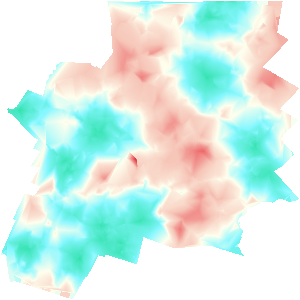

In [17]:
from scipy.interpolate import griddata
from shapely.ops import unary_union
import branca.colormap as cm
import matplotlib.colors as mcolors
import shapely

# --------------- interpolate drive times onto a regular grid ---------------
region = unary_union(counties.geometry)
minx, miny, maxx, maxy = region.bounds

GRID_RES = 300
lon_grid = np.linspace(minx, maxx, GRID_RES)
lat_grid = np.linspace(miny, maxy, GRID_RES)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

pts = drive_times_df[["lon", "lat"]].values
vals = drive_times_df["min_drive_minutes"].values

grid_z = griddata(pts, vals, (lon_mesh, lat_mesh), method="linear")
grid_nn = griddata(pts, vals, (lon_mesh, lat_mesh), method="nearest")
grid_z = np.where(np.isnan(grid_z), grid_nn, grid_z)
grid_z = np.clip(grid_z, 0, None)

# --------------- mask to county boundaries ---------------
grid_pts = shapely.points(lon_mesh.ravel(), lat_mesh.ravel())
inside = shapely.within(grid_pts, region).reshape(lon_mesh.shape)
grid_z[~inside] = np.nan

# --------------- build RGBA raster ---------------
CMAP_COLORS = ["#2ecc71", "#82e0aa", "#f9e79f", "#f0b27a", "#e74c3c", "#8b0000"]
CMAP_BREAKS = np.array([0, 10, 15, 20, 30, 45, 60], dtype=float)
CMAP_TARGETS = np.linspace(0, 1, len(CMAP_BREAKS))

_crgba = [mcolors.to_rgba(c) for c in CMAP_COLORS]
_pos = np.linspace(0, 1, len(CMAP_COLORS))
_cdict = {
    ch: [(_pos[i], _crgba[i][j], _crgba[i][j]) for i in range(len(_crgba))]
    for j, ch in enumerate(["red", "green", "blue"])
}
drive_cmap = mcolors.LinearSegmentedColormap("drive_time", _cdict)

normed = np.interp(np.clip(grid_z, 0, 60), CMAP_BREAKS, CMAP_TARGETS)
rgba = drive_cmap(normed)
rgba[..., 3] = np.where(np.isnan(grid_z), 0.0, 0.45)
rgba = np.flipud(rgba)  # rows run north→south for image display

# --------------- folium map ---------------
center_lat = drive_times_df["lat"].mean()
center_lon = drive_times_df["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="cartodbpositron")

folium.GeoJson(
    counties.__geo_interface__,
    name="County Boundaries",
    style_function=lambda _: {"fillOpacity": 0, "color": "#333333", "weight": 2},
    tooltip=folium.GeoJsonTooltip(fields=["county_name"], aliases=["County"]),
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=rgba,
    opacity=0.6,
    bounds=[[miny, minx], [maxy, maxx]],
    name="Drive Time Heatmap",
    interactive=False,
    zindex=1,
).add_to(m)

# Sample-point circles (toggleable)
sample_layer = folium.FeatureGroup(name="Sample Points", show=False)
for _, row in drive_times_df.iterrows():
    c = drive_cmap(np.interp(np.clip(row["min_drive_minutes"], 0, 60), CMAP_BREAKS, CMAP_TARGETS))
    hex_c = mcolors.to_hex(c)
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color=hex_c,
        fill=True,
        fill_color=hex_c,
        fill_opacity=0.8,
        weight=0,
        tooltip=f"{row.get('address_full', '')}: {row['min_drive_minutes']:.1f} min".strip(": "),
    ).add_to(sample_layer)
sample_layer.add_to(m)

# Pharmacy markers
pharm_layer = folium.FeatureGroup(name="Pharmacies")
for _, row in pharmacies.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color="#2c3e50",
        fill=True,
        fill_color="#3498db",
        fill_opacity=0.9,
        weight=1,
        tooltip=f"{row['name']} ({row['city']})",
    ).add_to(pharm_layer)
pharm_layer.add_to(m)

# Legend
colormap = cm.LinearColormap(
    colors=CMAP_COLORS + ["#8b0000"],
    index=[0, 10, 15, 20, 30, 45, 60],
    vmin=0,
    vmax=60,
    caption="Drive time to nearest pharmacy (minutes)",
)
colormap.add_to(m)

folium.LayerControl().add_to(m)
m

## 7. Descriptive Statistics

Summary statistics, histograms, and box plots describing pharmacy access across the four counties.

In [18]:
# Summary table: per-county and overall statistics
def compute_stats(df: pd.DataFrame, label: str) -> dict:
    d = df["min_drive_minutes"]
    total = len(d)
    return {
        "Region": label,
        "Sample Points": total,
        "Mean (min)": f"{d.mean():.1f}",
        "Median (min)": f"{d.median():.1f}",
        "Min (min)": f"{d.min():.1f}",
        "Max (min)": f"{d.max():.1f}",
        "P10 (min)": f"{d.quantile(0.10):.1f}",
        "P25 (min)": f"{d.quantile(0.25):.1f}",
        "P75 (min)": f"{d.quantile(0.75):.1f}",
        "P90 (min)": f"{d.quantile(0.90):.1f}",
        "% ≤ 10 min": f"{(d <= 10).sum() / total * 100:.1f}%",
        "% ≤ 15 min": f"{(d <= 15).sum() / total * 100:.1f}%",
        "% ≤ 20 min": f"{(d <= 20).sum() / total * 100:.1f}%",
        "% ≤ 30 min": f"{(d <= 30).sum() / total * 100:.1f}%",
    }


stats_rows = []
for county_name in sorted(TARGET_COUNTIES.keys()):
    subset = drive_times_df[drive_times_df["county_name"] == county_name]
    if len(subset) > 0:
        stats_rows.append(compute_stats(subset, county_name))

stats_rows.append(compute_stats(drive_times_df, "Overall"))

stats_table = pd.DataFrame(stats_rows).set_index("Region")
stats_table

,Sample Points,Mean (min),Median (min),Min (min),Max (min),P10 (min),P25 (min),P75 (min),P90 (min),% ≤ 10 min,% ≤ 15 min,% ≤ 20 min,% ≤ 30 min
Region,,,,,,,,,,,,,
Caledonia,560,15.2,15.1,1.1,39.0,5.2,8.4,21.0,25.3,31.8%,49.8%,69.8%,97.0%
Lamoille,459,9.8,8.8,0.6,25.8,3.4,5.1,13.3,18.1,56.4%,82.4%,93.5%,100.0%
Orleans,593,14.8,14.1,1.1,35.4,5.7,8.3,20.2,25.1,34.1%,52.1%,74.9%,98.0%
Washington,887,9.2,7.7,0.0,49.7,2.9,4.4,12.8,18.2,62.6%,83.4%,93.3%,99.8%
Overall,2500,12.0,10.6,0.0,49.7,3.7,5.9,17.1,22.5,47.8%,68.2%,83.7%,98.8%


/var/folders/qx/4l30h7752cs9nzzkxgfhg22c0000gn/T/ipykernel_71466/3945498575.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=county_order, patch_artist=True)


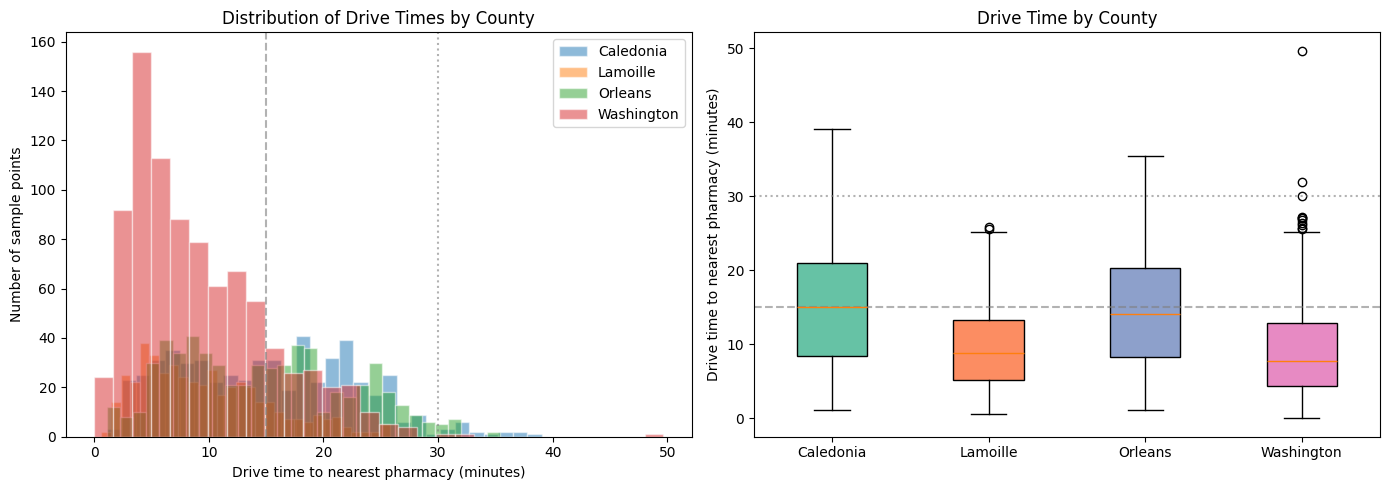

Saved to data/drive_time_stats.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
for county_name in sorted(TARGET_COUNTIES.keys()):
    subset = drive_times_df[drive_times_df["county_name"] == county_name]
    ax.hist(
        subset["min_drive_minutes"],
        bins=30,
        alpha=0.5,
        label=county_name,
        edgecolor="white",
    )
ax.set_xlabel("Drive time to nearest pharmacy (minutes)")
ax.set_ylabel("Number of sample points")
ax.set_title("Distribution of Drive Times by County")
ax.legend()
ax.axvline(x=15, color="gray", linestyle="--", alpha=0.6, label="15 min")
ax.axvline(x=30, color="gray", linestyle=":", alpha=0.6, label="30 min")

# Box plot
ax = axes[1]
county_order = sorted(TARGET_COUNTIES.keys())
plot_data = [
    drive_times_df[drive_times_df["county_name"] == c]["min_drive_minutes"].values
    for c in county_order
]
bp = ax.boxplot(plot_data, labels=county_order, patch_artist=True)
colors = sns.color_palette("Set2", len(county_order))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Drive time to nearest pharmacy (minutes)")
ax.set_title("Drive Time by County")
ax.axhline(y=15, color="gray", linestyle="--", alpha=0.6)
ax.axhline(y=30, color="gray", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(DATA_DIR / "drive_time_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/drive_time_stats.png")

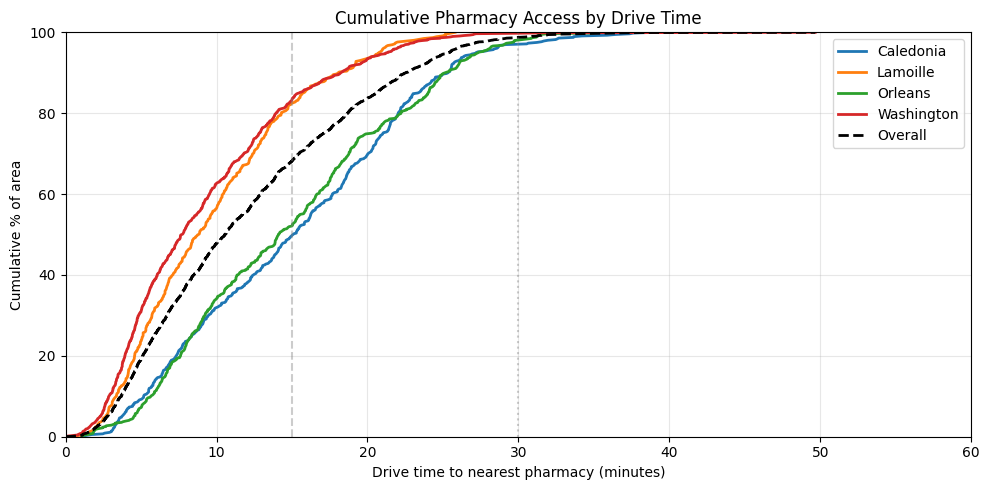

Saved to data/drive_time_cdf.png


In [20]:
# CDF: cumulative percentage of area within X minutes of a pharmacy
fig, ax = plt.subplots(figsize=(10, 5))

for county_name in sorted(TARGET_COUNTIES.keys()):
    subset = drive_times_df[drive_times_df["county_name"] == county_name]["min_drive_minutes"].sort_values()
    cdf = np.arange(1, len(subset) + 1) / len(subset) * 100
    ax.plot(subset.values, cdf, label=county_name, linewidth=2)

overall = drive_times_df["min_drive_minutes"].sort_values()
cdf_all = np.arange(1, len(overall) + 1) / len(overall) * 100
ax.plot(overall.values, cdf_all, label="Overall", linewidth=2, color="black", linestyle="--")

ax.set_xlabel("Drive time to nearest pharmacy (minutes)")
ax.set_ylabel("Cumulative % of area")
ax.set_title("Cumulative Pharmacy Access by Drive Time")
ax.legend()
ax.set_xlim(0, max(60, overall.max()))
ax.set_ylim(0, 100)
ax.axvline(x=15, color="gray", linestyle="--", alpha=0.4)
ax.axvline(x=30, color="gray", linestyle=":", alpha=0.4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "drive_time_cdf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/drive_time_cdf.png")

## 8. Scenario Analysis: Hypothetical Pharmacies

Define one or more hypothetical new pharmacy locations below, then run the subsequent cells to see how they would change drive times across the region.

Only the drive times to the **new** locations are computed (the baseline is fully cached). Each hypothetical pharmacy's results are cached independently by coordinates, so re-running the same scenario is free.

In [26]:
HYPOTHETICAL_PHARMACIES = [
    {"name": "Closed Walgreens - Hardwick", "lat": 44.513328369550734, "lon": -72.37213924836163}, # Site of old Brooks/Rite Aid/Walgreens
    # {"name": "Hypothetical - Somewhere", "lat": 44.0, "lon": -72.0},
]

if HYPOTHETICAL_PHARMACIES:
    hypo_df = pd.DataFrame(HYPOTHETICAL_PHARMACIES)
    print(f"Defined {len(hypo_df)} hypothetical pharmacies:")
    for _, row in hypo_df.iterrows():
        print(f"  + {row['name']}  ({row['lat']:.4f}, {row['lon']:.4f})")
else:
    hypo_df = pd.DataFrame(columns=["name", "lat", "lon"])
    print("No hypothetical pharmacies defined. Edit the list above and re-run.")

Defined 1 hypothetical pharmacies:
  + Closed Walgreens - Hardwick  (44.5133, -72.3721)


In [27]:
SCENARIO_CACHE = DATA_DIR / "scenario_drive_times.json"


def load_scenario_cache() -> dict:
    if SCENARIO_CACHE.exists():
        return json.loads(SCENARIO_CACHE.read_text())
    return {}


def save_scenario_cache(cache: dict):
    SCENARIO_CACHE.write_text(json.dumps(cache))


def compute_hypothetical_drive_times(
    addrs: pd.DataFrame, hypo: pd.DataFrame, api_key: str
) -> np.ndarray:
    """Compute drive time from every address to each hypothetical pharmacy.

    Returns array of shape (n_addrs,) with the min drive time across all
    hypothetical pharmacies. Results are cached per pharmacy coordinate.
    """
    n_addrs = len(addrs)
    best = np.full(n_addrs, np.nan)
    cache = load_scenario_cache()
    total_elements = n_addrs * len(hypo)
    elements_used = 0
    api_calls = 0

    for _, pharm in hypo.iterrows():
        key = f"{pharm['lat']:.6f},{pharm['lon']:.6f}"
        cached_entry = cache.get(key, {})
        dest = [(pharm["lat"], pharm["lon"])]

        for batch_start in range(0, n_addrs, BATCH_SIZE):
            batch_end = min(batch_start + BATCH_SIZE, n_addrs)
            batch_indices = list(range(batch_start, batch_end))

            uncached = [i for i in batch_indices if str(i) not in cached_entry]
            if not uncached:
                elements_used += len(batch_indices)
                continue

            origins = [(addrs.iloc[i]["lat"], addrs.iloc[i]["lon"]) for i in batch_indices]
            elements_used += len(origins)
            api_calls += 1

            result = call_route_matrix(origins, dest, api_key)
            for elem in result:
                if "originIndex" not in elem or "duration" not in elem:
                    continue
                if elem.get("condition") == "ROUTE_NOT_FOUND":
                    continue
                dur_str = elem["duration"]
                seconds = int(dur_str.rstrip("s"))
                addr_i = batch_start + elem["originIndex"]
                cached_entry[str(addr_i)] = seconds / 60.0

            cache[key] = cached_entry
            save_scenario_cache(cache)
            time.sleep(REQUEST_DELAY)

        for i in range(n_addrs):
            mins = cached_entry.get(str(i))
            if mins is not None:
                if np.isnan(best[i]) or mins < best[i]:
                    best[i] = mins

        print(f"  {pharm['name']}: done ({elements_used}/{total_elements} elements, {api_calls} API calls)")

    print(f"\nTotal: {elements_used} elements, {api_calls} API calls")
    return best


if len(hypo_df) > 0:
    print(f"Computing drive times to {len(hypo_df)} hypothetical pharmacies...\n")
    hypo_minutes = compute_hypothetical_drive_times(addresses, hypo_df, GOOGLE_API_KEY)

    scenario_df = drive_times_df.copy()
    scenario_df["baseline_minutes"] = scenario_df["min_drive_minutes"]
    scenario_df["hypo_minutes"] = hypo_minutes[scenario_df.index]
    scenario_df["min_drive_minutes"] = np.minimum(
        scenario_df["baseline_minutes"], scenario_df["hypo_minutes"]
    )
    scenario_df["improvement_minutes"] = (
        scenario_df["baseline_minutes"] - scenario_df["min_drive_minutes"]
    )
    improved = (scenario_df["improvement_minutes"] > 0).sum()
    print(f"\n{improved} of {len(scenario_df)} addresses improved")
    print(f"Mean improvement (where improved): "
          f"{scenario_df.loc[scenario_df['improvement_minutes'] > 0, 'improvement_minutes'].mean():.1f} min")
else:
    scenario_df = None
    print("No hypothetical pharmacies defined — skipping scenario computation.")

Computing drive times to 1 hypothetical pharmacies...

  Closed Walgreens - Hardwick: done (2500/2500 elements, 0 API calls)

Total: 2500 elements, 0 API calls

200 of 2500 addresses improved
Mean improvement (where improved): 10.1 min


In [28]:
if scenario_df is not None:
    baseline_stats = []
    scenario_stats = []
    for county_name in sorted(TARGET_COUNTIES.keys()):
        bl_sub = drive_times_df[drive_times_df["county_name"] == county_name]
        sc_sub = scenario_df[scenario_df["county_name"] == county_name]
        if len(bl_sub) > 0:
            baseline_stats.append(compute_stats(bl_sub, county_name))
            scenario_stats.append(compute_stats(sc_sub, county_name))
    baseline_stats.append(compute_stats(drive_times_df, "Overall"))
    scenario_stats.append(compute_stats(scenario_df, "Overall"))

    bl_table = pd.DataFrame(baseline_stats).set_index("Region").add_suffix(" (baseline)")
    sc_table = pd.DataFrame(scenario_stats).set_index("Region").add_suffix(" (scenario)")

    comparison = pd.concat([bl_table, sc_table], axis=1)
    cols = []
    for base_col in bl_table.columns:
        cols.append(base_col)
        sc_col = base_col.replace("(baseline)", "(scenario)")
        if sc_col in sc_table.columns:
            cols.append(sc_col)
    comparison = comparison[cols]

    print("Baseline vs Scenario comparison:")
    display(comparison)
else:
    print("No scenario to compare.")

Baseline vs Scenario comparison:


,Sample Points (baseline),Sample Points (scenario),Mean (min) (baseline),Mean (min) (scenario),Median (min) (baseline),Median (min) (scenario),Min (min) (baseline),Min (min) (scenario),Max (min) (baseline),Max (min) (scenario),...,P90 (min) (baseline),P90 (min) (scenario),% ≤ 10 min (baseline),% ≤ 10 min (scenario),% ≤ 15 min (baseline),% ≤ 15 min (scenario),% ≤ 20 min (baseline),% ≤ 20 min (scenario),% ≤ 30 min (baseline),% ≤ 30 min (scenario)
Region,,,,,,,,,,,,,,,,,,,,,
Caledonia,560,560,15.2,13.0,15.1,12.3,1.1,1.1,39.0,35.9,...,25.3,22.4,31.8%,41.4%,49.8%,62.0%,69.8%,80.2%,97.0%,98.0%
Lamoille,459,459,9.8,9.7,8.8,8.7,0.6,0.6,25.8,25.8,...,18.1,17.9,56.4%,57.1%,82.4%,83.0%,93.5%,93.9%,100.0%,100.0%
Orleans,593,593,14.8,14.0,14.1,13.9,1.1,1.1,35.4,35.4,...,25.1,24.0,34.1%,34.2%,52.1%,55.5%,74.9%,81.5%,98.0%,98.8%
Washington,887,887,9.2,8.9,7.7,7.7,0.0,0.0,49.7,33.6,...,18.2,16.6,62.6%,62.8%,83.4%,85.8%,93.3%,96.7%,99.8%,99.8%
Overall,2500,2500,12.0,11.2,10.6,9.9,0.0,0.0,49.7,35.9,...,22.5,20.7,47.8%,50.2%,68.2%,72.7%,83.7%,88.9%,98.8%,99.2%


Scenario heat map (purple markers = hypothetical pharmacies)



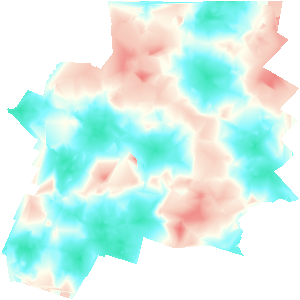

In [32]:
if scenario_df is not None:
    # --------------- interpolate scenario drive times ---------------
    scn_pts = scenario_df[["lon", "lat"]].values
    scn_vals = scenario_df["min_drive_minutes"].values

    scn_z = griddata(scn_pts, scn_vals, (lon_mesh, lat_mesh), method="linear")
    scn_nn = griddata(scn_pts, scn_vals, (lon_mesh, lat_mesh), method="nearest")
    scn_z = np.where(np.isnan(scn_z), scn_nn, scn_z)
    scn_z = np.clip(scn_z, 0, None)
    scn_z[~inside] = np.nan

    scn_normed = np.interp(np.clip(scn_z, 0, 60), CMAP_BREAKS, CMAP_TARGETS)
    scn_rgba = drive_cmap(scn_normed)
    scn_rgba[..., 3] = np.where(np.isnan(scn_z), 0.0, 0.45)
    scn_rgba = np.flipud(scn_rgba)

    # --------------- folium map ---------------
    center_lat = scenario_df["lat"].mean()
    center_lon = scenario_df["lon"].mean()

    m_scenario = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="cartodbpositron")

    folium.GeoJson(
        counties.__geo_interface__,
        name="County Boundaries",
        style_function=lambda _: {"fillOpacity": 0, "color": "#333333", "weight": 2},
        tooltip=folium.GeoJsonTooltip(fields=["county_name"], aliases=["County"]),
    ).add_to(m_scenario)

    folium.raster_layers.ImageOverlay(
        image=scn_rgba,
        opacity=0.6,
        bounds=[[miny, minx], [maxy, maxx]],
        name="Drive Time Heatmap",
        interactive=False,
        zindex=1,
    ).add_to(m_scenario)

    # Pharmacy markers
    pharm_layer = folium.FeatureGroup(name="Pharmacies")
    for _, row in pharmacies.iterrows():
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=6,
            color="#2c3e50",
            fill=True,
            fill_color="#3498db",
            fill_opacity=0.9,
            weight=1,
            tooltip=f"{row['name']} ({row['city']})",
        ).add_to(pharm_layer)
    pharm_layer.add_to(m_scenario)

    # Hypothetical pharmacy markers
    for _, row in hypo_df.iterrows():
        folium.Marker(
            location=[row["lat"], row["lon"]],
            icon=folium.Icon(color="purple", icon="plus", prefix="fa"),
            tooltip=row["name"],
        ).add_to(m_scenario)

    colormap = cm.LinearColormap(
        colors=CMAP_COLORS + ["#8b0000"],
        index=[0, 10, 15, 20, 30, 45, 60],
        vmin=0, vmax=60,
        caption="Drive time to nearest pharmacy (minutes) \u2014 with hypothetical",
    )
    colormap.add_to(m_scenario)
    folium.LayerControl().add_to(m_scenario)

    print("Scenario heat map (purple markers = hypothetical pharmacies)")
    m_scenario
else:
    print("No scenario to map.")

m_scenario


In [31]:
if scenario_df is not None:
    def improvement_color(delta_min: float) -> str:
        if delta_min <= 0:
            return "#cccccc"   # gray — no change
        elif delta_min < 3:
            return "#a9dfbf"   # light green
        elif delta_min < 5:
            return "#52be80"   # medium green
        elif delta_min < 10:
            return "#27ae60"   # green
        else:
            return "#1a5276"   # dark teal

    m_improve = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="cartodbpositron")

    folium.GeoJson(
        counties.__geo_interface__,
        name="County Boundaries",
        style_function=lambda _: {"fillOpacity": 0.02, "color": "#333333", "weight": 2},
    ).add_to(m_improve)

    for _, row in scenario_df.iterrows():
        delta = row["improvement_minutes"]
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=4,
            color=improvement_color(delta),
            fill=True,
            fill_color=improvement_color(delta),
            fill_opacity=0.7,
            weight=0,
            tooltip=(f"{row.get('address_full', '')}: "
                     f"{row['baseline_minutes']:.1f} → {row['min_drive_minutes']:.1f} min "
                     f"({delta:+.1f} min)"),
        ).add_to(m_improve)

    for _, row in hypo_df.iterrows():
        folium.Marker(
            location=[row["lat"], row["lon"]],
            icon=folium.Icon(color="purple", icon="plus", prefix="fa"),
            tooltip=row["name"],
        ).add_to(m_improve)

    imp_colormap = cm.LinearColormap(
        colors=["#cccccc", "#a9dfbf", "#52be80", "#27ae60", "#1a5276"],
        index=[0, 1, 3, 5, 10],
        vmin=0, vmax=15,
        caption="Improvement in drive time (minutes saved)",
    )
    imp_colormap.add_to(m_improve)

    print("Improvement map (green = addresses with reduced drive time, gray = no change)")
    m_improve
else:
    print("No scenario to map.")

m_improve

Improvement map (green = addresses with reduced drive time, gray = no change)


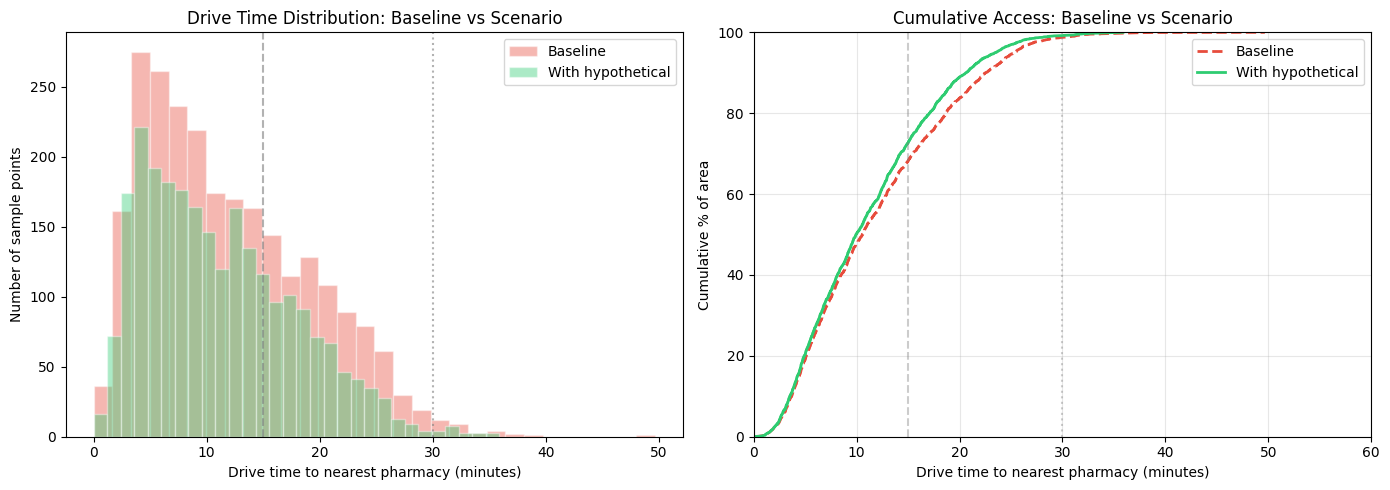

Saved to data/scenario_comparison.png


In [25]:
if scenario_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overlaid histograms
    ax = axes[0]
    ax.hist(drive_times_df["min_drive_minutes"], bins=30, alpha=0.4,
            label="Baseline", color="#e74c3c", edgecolor="white")
    ax.hist(scenario_df["min_drive_minutes"], bins=30, alpha=0.4,
            label="With hypothetical", color="#2ecc71", edgecolor="white")
    ax.set_xlabel("Drive time to nearest pharmacy (minutes)")
    ax.set_ylabel("Number of sample points")
    ax.set_title("Drive Time Distribution: Baseline vs Scenario")
    ax.legend()
    ax.axvline(x=15, color="gray", linestyle="--", alpha=0.6)
    ax.axvline(x=30, color="gray", linestyle=":", alpha=0.6)

    # Overlaid CDFs
    ax = axes[1]
    bl_sorted = drive_times_df["min_drive_minutes"].sort_values()
    bl_cdf = np.arange(1, len(bl_sorted) + 1) / len(bl_sorted) * 100
    ax.plot(bl_sorted.values, bl_cdf, label="Baseline", linewidth=2,
            color="#e74c3c", linestyle="--")

    sc_sorted = scenario_df["min_drive_minutes"].sort_values()
    sc_cdf = np.arange(1, len(sc_sorted) + 1) / len(sc_sorted) * 100
    ax.plot(sc_sorted.values, sc_cdf, label="With hypothetical", linewidth=2,
            color="#2ecc71")

    ax.set_xlabel("Drive time to nearest pharmacy (minutes)")
    ax.set_ylabel("Cumulative % of area")
    ax.set_title("Cumulative Access: Baseline vs Scenario")
    ax.legend()
    ax.set_xlim(0, max(60, bl_sorted.max()))
    ax.set_ylim(0, 100)
    ax.axvline(x=15, color="gray", linestyle="--", alpha=0.4)
    ax.axvline(x=30, color="gray", linestyle=":", alpha=0.4)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(DATA_DIR / "scenario_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to data/scenario_comparison.png")
else:
    print("No scenario to chart.")

## Save Map to HTML

Export the interactive map as a standalone HTML file for sharing.

In [ ]:
map_path = DATA_DIR / "pharmacy_access_map.html"
m.save(str(map_path))
print(f"Interactive map saved to {map_path}")

Interactive map saved to ../data/pharmacy_access_map.html
